# Notebook 26 — MJO Barlow Twins (τ-graded, D=7 NSV-matched)
**Project:** ENSO-BSISO SSL — MJO extension  
**Author:** Jiayi (jh9141@nyu.edu)

Self-supervised **Barlow Twins** (Zbontar et al. 2021) on the MJO intraseasonal field, with the project-specific **temporally-graded loss** decided in Session 36 of the conversation log.

## Method

Two views = a frame and a **τ-day-later** frame `(X_t, X_{t+τ})`, τ ∈ {1,2,3,4,5}. Encoder `f` (warm-started from the MJO NSV Stage-1 encoder) → 64-D, then a small projector → **D=7** (matching the MJO NSV intrinsic dimension d̂=7). On the 7×7 cross-correlation matrix `C(τ)`:

$$\mathcal{L}(\tau) = \lambda_\text{inv}(\tau)\sum_i (1 - C_{ii}(\tau))^2 \; + \; \lambda_\text{off}(\tau)\sum_i\sum_{j\neq i} C_{ij}(\tau)^2$$

**Both** terms are τ-graded (Session-36 decision #1): `λ(τ)` decays linearly 1.0→0.5 as τ goes 1→5 d. Physical motive: the slow mode drifts over longer τ, so strict invariance should relax. `λ_inv(τ) = sched(τ)`; `λ_off(τ) = LAMBDA_OFF_BASE · sched(τ)` (keeps the Barlow diagonal/off-diagonal balance while grading both).

## Decisions (Session 36, resolved 2026-06-12)
1. off-diagonal **also** τ-graded — both terms scaled by `sched(τ)`.
2. input = MJO daily-mean `X_MJO_bp20_90` (Lee + Lanczos 20–90 d bandpass).
3. warm-start the **MJO Stage-1 encoder** (`EncoderMJO`, nb21) — *not* nb18c (that is BSISO 2-D; shapes incompatible).
4. small projector sized for D≈7: `64 → 128 → 64 → 7`.
5. new notebook after the NSV chapter (this is nb26).

## Inputs (`MJO/data/processed/` + `MJO/nsv/`)
- `X_MJO_bp20_90.npy` `(N, 3, 1, 180)`, `labels_aligned_mjo_bp20_90.csv` (phase, amplitude, enso_category, weak_mjo, date)
- `MJO/nsv/checkpoints_lag10/encoder_stage1_best.pth` (warm-start)

## ⚠️ Prerequisite
Both the bp20-90 input and the Stage-1 encoder come from the **MJO NSV pipeline (nb21)**, whose full-daily rerun was deferred (Session 35). Refresh them on the full 1979–2023 daily data before trusting these numbers. Cell 2 mtime-checks the input; Cell 4 reports the encoder's date.

## Outputs (`MJO/barlow/`)
`encoder_bt.pth`, `projector_bt.pth`, `embeddings_z7.npy`, `embeddings_f64.npy`, `training_history.json`, `bt_diagnostics.png`, `bt_probe_results.json`, `bt_summary.md`

---

## Cell 1 — Setup + Config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

PROJECT_DIR   = '/content/drive/MyDrive/BSISO_SSL_Project'
MJO_DIR       = f'{PROJECT_DIR}/MJO'
PROCESSED_DIR = f'{MJO_DIR}/data/processed'
NSV_CKPT_DIR  = f'{MJO_DIR}/nsv/checkpoints_lag10'
OUT_BASE      = f'{MJO_DIR}/barlow'

# ---- config ----
TAUS            = [1, 2, 3, 4, 5]      # day-lags for the two views
PROJ_DIM        = 3                    # embedding / cross-correlation dim (try 3; was 7 = MJO d_hat)
LATENT_DIM      = 64                   # encoder output (matches nb21)
LAMBDA_OFF_BASE = 5e-3                 # Barlow off-diagonal weight (paper default); tune for small D
BATCH_SIZE      = 256
EPOCHS          = 100
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
WARM_START      = True                 # load nb21 Stage-1 encoder weights
SEED            = 42
VAL_YEARS_STRIDE = 5

# per-dim output folder so D=3 and D=7 runs don't overwrite each other
OUT_DIR = f'{OUT_BASE}/D{PROJ_DIM}'
os.makedirs(OUT_DIR, exist_ok=True)

# ---- tau-grading schedule (Session 44 fix) ----
# STEEP decay so invariance is enforced mainly at tau=1 (where the MJO phase is ~unchanged)
# and barely at tau=5 (where the MJO has propagated). Set LAMBDA_TAU_MIN=0.5, SCHED_MODE='linear'
# to recover the run-1 schedule.
LAMBDA_TAU_MAX = 1.0                   # weight at tau=1
LAMBDA_TAU_MIN = 0.05                  # weight at tau=max
SCHED_MODE     = 'exp'                 # 'exp' (geometric) or 'linear'

def sched(tau):
    f = (tau - min(TAUS)) / (max(TAUS) - min(TAUS))           # 0..1
    if SCHED_MODE == 'exp':
        return LAMBDA_TAU_MAX * (LAMBDA_TAU_MIN / LAMBDA_TAU_MAX) ** f
    return LAMBDA_TAU_MAX + (LAMBDA_TAU_MIN - LAMBDA_TAU_MAX) * f

torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}   proj_dim D={PROJ_DIM}   taus={TAUS}   out={OUT_DIR}')
print(f'lambda(tau) schedule ({SCHED_MODE}, {LAMBDA_TAU_MAX}->{LAMBDA_TAU_MIN}):',
      {t: round(sched(t), 3) for t in TAUS})
if device.type != 'cuda':
    print('WARNING: no GPU - switch Colab runtime to T4.')

## Cell 2 — Load bp20-90 Data + Freshness Check + Year Split

In [ ]:
X_FILE      = 'X_MJO_bp20_90.npy'
LABELS_FILE = 'labels_aligned_mjo_bp20_90.csv'

X      = np.load(f'{PROCESSED_DIR}/{X_FILE}')
labels = pd.read_csv(f'{PROCESSED_DIR}/{LABELS_FILE}', parse_dates=['date'])
labels['date'] = labels['date'].dt.normalize()
assert X.shape[0] == len(labels), f'X/labels mismatch: {X.shape[0]} vs {len(labels)}'
assert X.shape[1:] == (3, 1, 180), f'unexpected X shape {X.shape[1:]}'

# freshness vs raw OLR (same idea as nb24): warn if the bp20-90 input predates the daily download
RAW_DIR = f'{MJO_DIR}/data/raw'
raw_olr = [f'{RAW_DIR}/{f}' for f in os.listdir(RAW_DIR) if f.startswith('OLR_MJO_') and f.endswith('.nc')] \
          if os.path.isdir(RAW_DIR) else []
if raw_olr:
    dh = (os.path.getmtime(f'{PROCESSED_DIR}/{X_FILE}') - max(os.path.getmtime(f) for f in raw_olr)) / 3600
    print(f'X_bp20_90 mtime - newest raw OLR = {dh:+.1f} h')
    if dh < 0:
        print('  ⚠️ bp20-90 input is OLDER than raw OLR — rerun MJO bp20-90 preprocessing + nb21 on full daily data.')

# squeeze singleton lat → (N, 3, 180); sort by date defensively
order = np.argsort(labels['date'].values)
if not np.array_equal(order, np.arange(len(labels))):
    X = X[order]; labels = labels.iloc[order].reset_index(drop=True)
X = X.reshape(X.shape[0], 3, 180).astype(np.float32)
N = X.shape[0]
dates_all = pd.DatetimeIndex(labels['date'].values)
years_all = dates_all.year.values
print(f'X: {X.shape}  ({dates_all.min().date()} .. {dates_all.max().date()})')

all_years   = sorted(np.unique(years_all).tolist())
val_years   = all_years[::VAL_YEARS_STRIDE]
train_years = sorted(set(all_years) - set(val_years))
is_val_day  = np.isin(years_all, val_years)
print(f'Val years ({len(val_years)}): {val_years}')

Xt = torch.from_numpy(X)   # keep one CPU copy; datasets index into it

## Cell 3 — Multi-τ Pair Construction (same-split, per τ)

For each τ build `(anchor, target)` index pairs with `delta_days == τ` and anchor/target in the **same** split (no train↔val leakage). One train DataLoader per τ; each batch is a single τ so the 7×7 cross-correlation is computed on a uniform-τ batch.

In [ ]:
class PairIdxDataset(Dataset):
    def __init__(self, Xt, idx_t, idx_t1):
        self.Xt = Xt; self.idx_t = idx_t; self.idx_t1 = idx_t1
    def __len__(self): return len(self.idx_t)
    def __getitem__(self, k): return self.Xt[self.idx_t[k]], self.Xt[self.idx_t1[k]]

def build_pairs(tau):
    delta = (dates_all[tau:] - dates_all[:-tau]).days
    same_split = is_val_day[:-tau] == is_val_day[tau:]
    valid = (delta == tau) & same_split
    it  = np.where(valid)[0]
    it1 = it + tau
    return it, it1

train_loaders, val_loaders, pair_counts = {}, {}, {}
for tau in TAUS:
    it, it1 = build_pairs(tau)
    anchor_val = is_val_day[it]
    tr = ~anchor_val; va = anchor_val
    train_loaders[tau] = DataLoader(PairIdxDataset(Xt, it[tr], it1[tr]),
                                    batch_size=BATCH_SIZE, shuffle=True,
                                    num_workers=2, pin_memory=(device.type=='cuda'), drop_last=True)
    val_loaders[tau]   = DataLoader(PairIdxDataset(Xt, it[va], it1[va]),
                                    batch_size=BATCH_SIZE, shuffle=False,
                                    num_workers=2, pin_memory=(device.type=='cuda'))
    pair_counts[tau] = {'train': int(tr.sum()), 'val': int(va.sum())}
    print(f'τ={tau}: {int(tr.sum())} train / {int(va.sum())} val pairs')

## Cell 4 — Encoder (warm-start from nb21) + Projector + Barlow Loss

In [ ]:
class EncoderMJO(nn.Module):
    """1-D CNN encoder (identical to nb21 so the Stage-1 checkpoint loads)."""
    def __init__(self, latent_dim=64):
        super().__init__()
        self.conv1 = nn.Conv1d(3,   16,  4, 2, 1, bias=False); self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16,  32,  3, 1, 1, bias=False); self.bn2 = nn.BatchNorm1d(32)
        self.conv3 = nn.Conv1d(32,  32,  4, 2, 1, bias=False); self.bn3 = nn.BatchNorm1d(32)
        self.conv4 = nn.Conv1d(32,  64,  3, 1, 1, bias=False); self.bn4 = nn.BatchNorm1d(64)
        self.conv5 = nn.Conv1d(64,  128, 4, 2, 1, bias=False); self.bn5 = nn.BatchNorm1d(128)
        self.gap   = nn.AdaptiveAvgPool1d(1)
        self.fc    = nn.Linear(128, latent_dim)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        return self.fc(self.gap(x).flatten(1))


class Projector(nn.Module):
    """64 → 128 → 64 → D (BN+ReLU between layers). Small, NSV-sized output."""
    def __init__(self, in_dim=64, out_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.ReLU(inplace=True),
            nn.Linear(64, out_dim))
    def forward(self, x): return self.net(x)


encoder   = EncoderMJO(LATENT_DIM).to(device)
projector = Projector(LATENT_DIM, PROJ_DIM).to(device)

ckpt = f'{NSV_CKPT_DIR}/encoder_stage1_best.pth'
if WARM_START and os.path.exists(ckpt):
    encoder.load_state_dict(torch.load(ckpt, map_location=device))
    mt = time.strftime('%Y-%m-%d', time.localtime(os.path.getmtime(ckpt)))
    print(f'Warm-started encoder from nb21 Stage-1 ({mt}).')
else:
    print('Encoder trained from scratch (no warm-start checkpoint found).' if WARM_START else 'Cold-start encoder.')


def barlow_cross_corr(zA, zB, eps=1e-5):
    """Batch-normalized cross-correlation matrix C (D,D) in [-1,1]."""
    zA = (zA - zA.mean(0)) / (zA.std(0) + eps)
    zB = (zB - zB.mean(0)) / (zB.std(0) + eps)
    return (zA.T @ zB) / zA.size(0)

def barlow_loss(C, lam_inv, lam_off):
    on  = torch.diagonal(C).add(-1.0).pow(2).sum()
    off = (C - torch.diag(torch.diagonal(C))).pow(2).sum()
    return lam_inv * on + lam_off * off, on.item(), off.item()

_z = projector(encoder(torch.randn(8, 3, 180).to(device)))
print(f'projector out: {tuple(_z.shape)}  (expect (8, {PROJ_DIM}))')

## Cell 5 — Training (per-τ Barlow loss, τ-graded λ)

Each epoch interleaves one batch from every τ-loader; the batch's loss uses `λ_inv(τ)=sched(τ)` and `λ_off(τ)=LAMBDA_OFF_BASE·sched(τ)`. Per-τ on/off-diagonal means are tracked to monitor how invariance relaxes with τ.

In [ ]:
from itertools import cycle

opt = optim.Adam(list(encoder.parameters()) + list(projector.parameters()),
                 lr=LR, weight_decay=WEIGHT_DECAY)
sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=LR * 0.01)

hist = {'epoch_loss': [], 'on_by_tau': {t: [] for t in TAUS}, 'off_by_tau': {t: [] for t in TAUS}}
steps_per_epoch = min(len(train_loaders[t]) for t in TAUS)
best_loss, best_state = float('inf'), None
t0 = time.time()

# Fixed per-tau eval batch so the recorded C(tau) is comparable across epochs.
eval_batches = {}
for t in TAUS:
    xa, xb = next(iter(val_loaders[t]))
    eval_batches[t] = (xa.to(device), xb.to(device))
C_hist = {t: [] for t in TAUS}          # C_hist[tau] -> list of (D,D) matrices, one per recorded epoch

def record_C():
    """Snapshot the DxD cross-correlation C(tau) on the fixed eval batch (no grad)."""
    encoder.eval(); projector.eval()
    with torch.no_grad():
        for t in TAUS:
            xa, xb = eval_batches[t]
            C = barlow_cross_corr(projector(encoder(xa)), projector(encoder(xb)))
            C_hist[t].append(C.cpu().numpy())
    encoder.train(); projector.train()

record_C()                              # index 0 = initial (untrained) C

for ep in range(EPOCHS):
    encoder.train(); projector.train()
    iters = {t: iter(train_loaders[t]) for t in TAUS}
    ep_loss = 0.0; on_acc = {t: 0.0 for t in TAUS}; off_acc = {t: 0.0 for t in TAUS}
    for _ in range(steps_per_epoch):
        opt.zero_grad(); total = 0.0
        for tau in TAUS:
            xa, xb = next(iters[tau])
            xa = xa.to(device, non_blocking=True); xb = xb.to(device, non_blocking=True)
            C = barlow_cross_corr(projector(encoder(xa)), projector(encoder(xb)))
            loss, on, off = barlow_loss(C, sched(tau), LAMBDA_OFF_BASE * sched(tau))
            total = total + loss
            on_acc[tau] += on / PROJ_DIM            # mean (1-C_ii)^2 per dim
            off_acc[tau] += off / (PROJ_DIM * (PROJ_DIM - 1))
        total.backward(); opt.step()
        ep_loss += total.item()
    sch.step()
    record_C()                          # index ep+1 = C after this epoch
    hist['epoch_loss'].append(ep_loss / steps_per_epoch)
    for t in TAUS:
        hist['on_by_tau'][t].append(on_acc[t] / steps_per_epoch)
        hist['off_by_tau'][t].append(off_acc[t] / steps_per_epoch)
    if hist['epoch_loss'][-1] < best_loss:
        best_loss = hist['epoch_loss'][-1]
        best_state = (copy.deepcopy(encoder.state_dict()), copy.deepcopy(projector.state_dict()))
    if (ep + 1) % 10 == 0 or ep < 3:
        on1 = hist['on_by_tau'][1][-1]; on5 = hist['on_by_tau'][5][-1]
        print(f'ep {ep+1:3d}/{EPOCHS}  loss={hist["epoch_loss"][-1]:.4f}  '
              f'on(τ1)={on1:.3f} on(τ5)={on5:.3f}  lr={sch.get_last_lr()[0]:.1e}')

if best_state is not None:
    encoder.load_state_dict(best_state[0]); projector.load_state_dict(best_state[1])
torch.save(encoder.state_dict(),   f'{OUT_DIR}/encoder_bt.pth')
torch.save(projector.state_dict(), f'{OUT_DIR}/projector_bt.pth')
with open(f'{OUT_DIR}/training_history.json', 'w') as f:
    json.dump(hist, f, indent=2)
# Save the C(tau) evolution (epochs x D x D per tau) for the heatmap/slider cells + nb27.
np.savez(f'{OUT_DIR}/bt_corr_history.npz',
         taus=np.array(TAUS), lambdas=np.array([sched(t) for t in TAUS], dtype=float),
         lambda_off_base=LAMBDA_OFF_BASE, proj_dim=PROJ_DIM,
         **{f'C_tau{t}': np.array(C_hist[t]) for t in TAUS})
print(f'\nDone in {(time.time()-t0)/60:.1f} min. best loss={best_loss:.4f}. '
      f'Recorded C(tau) for {len(C_hist[TAUS[0]])} epoch-snapshots -> bt_corr_history.npz')

## Cell 6 — Diagnostics: per-τ Invariance Trajectory

On-diagonal (1−C_ii)² should fall toward 0; off-diagonal C_ij² toward 0. Under the τ-graded loss we expect **invariance to relax with τ** — longer-τ pairs settle at a *higher* residual on-diagonal (the mode drifted), which is the slow-evolution signal we set out to monitor.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(hist['epoch_loss'], lw=2); axes[0].set_title('Total τ-graded Barlow loss', fontweight='bold')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].grid(alpha=0.3)

cmap = plt.cm.viridis(np.linspace(0, 0.9, len(TAUS)))
for c, t in zip(cmap, TAUS):
    axes[1].plot(hist['on_by_tau'][t], color=c, lw=2, label=f'τ={t}')
    axes[2].plot(hist['off_by_tau'][t], color=c, lw=2, label=f'τ={t}')
axes[1].set_title('On-diagonal mean (1−C_ii)²  (invariance)', fontweight='bold')
axes[2].set_title('Off-diagonal mean C_ij²  (redundancy)', fontweight='bold')
for ax in axes[1:]:
    ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/bt_diagnostics.png', dpi=140, bbox_inches='tight'); plt.show()

print('Final on-diagonal (1−C_ii)² by τ (higher = more drift / relaxed invariance):')
for t in TAUS:
    print(f'  τ={t}: on={hist["on_by_tau"][t][-1]:.4f}  off={hist["off_by_tau"][t][-1]:.4f}')

## Cell 6b — How C(τ) is Computed + Its Evolution (static heatmap grid)

**How the matrix is formed:** each training step takes the two views' projector outputs `zA, zB` (shape B×D), **batch-normalizes each column** (mean 0, std 1 per dim), then forms the D×D cross-correlation `C(τ)_ij = (1/B) Σ_b ẑA_{b,i} ẑB_{b,j} ∈ [−1,1]` (`barlow_cross_corr`, Cell 4). The loss pulls the **diagonal → 1** (invariance) and the **off-diagonal → 0** (decorrelation), each scaled by the τ-graded weight: `L(τ) = λ_inv(τ)·Σ(1−C_ii)² + λ_off(τ)·Σ_{i≠j}C_ij²`, with `λ_inv(τ)=sched(τ)`, `λ_off(τ)=LAMBDA_OFF_BASE·sched(τ)`.

Cell 5 now records `C(τ)` once per epoch on a fixed eval batch (`C_hist`, saved to `bt_corr_history.npz`). This grid shows it forming over training — rows = τ, columns = selected epochs (init → final). **Requires a fresh training run (Cell 5)** since per-epoch C wasn't recorded before.

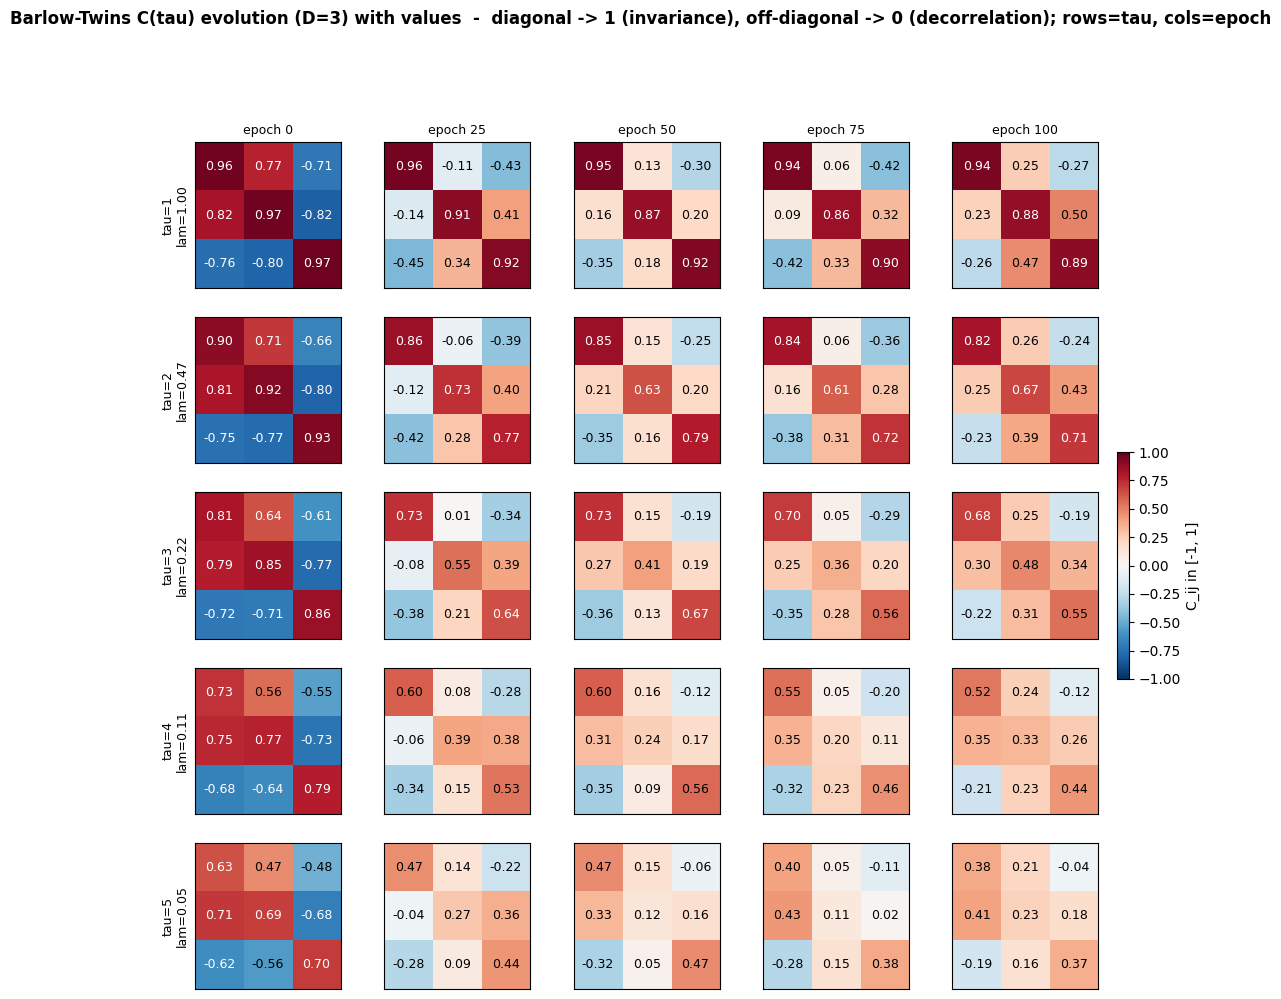

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/barlow/D3/bt_corr_evolution.png
Final-epoch C(tau) summary:
  tau=1 lam=1.00: mean diag=0.904  mean|off-diag|=0.328
  tau=2 lam=0.47: mean diag=0.735  mean|off-diag|=0.299
  tau=3 lam=0.22: mean diag=0.570  mean|off-diag|=0.268
  tau=4 lam=0.11: mean diag=0.432  mean|off-diag|=0.232
  tau=5 lam=0.05: mean diag=0.325  mean|off-diag|=0.196


In [15]:
# --- C(tau) evolution: STATIC heatmap grid WITH exact values (rows=tau, cols=epochs) ---
import os, glob, numpy as np, matplotlib.pyplot as plt

if 'C_hist' in globals() and len(C_hist.get(TAUS[0], [])) > 0:        # fresh after Cell 5
    taus = list(TAUS); lams = [sched(t) for t in taus]
    Chist = {t: np.asarray(C_hist[t]) for t in taus}; outdir = OUT_DIR
else:                                                                # load saved npz (no retrain)
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive; drive.mount('/content/drive')
    MJO_DIR = '/content/drive/MyDrive/BSISO_SSL_Project/MJO'
    hits = sorted(glob.glob(f'{MJO_DIR}/barlow/**/bt_corr_history.npz', recursive=True))
    pref = [globals().get('OUT_DIR', '') + '/bt_corr_history.npz',
            f'{MJO_DIR}/barlow/D3/bt_corr_history.npz', f'{MJO_DIR}/barlow/bt_corr_history.npz']
    npz = next((p for p in pref if p in hits), (hits[0] if hits else None))
    assert npz, 'No bt_corr_history.npz found -> run nb26 Cell 5 (updated) once.'
    d = np.load(npz); taus = d['taus'].tolist(); lams = d['lambdas'].tolist(); outdir = os.path.dirname(npz)
    Chist = {t: d[f'C_tau{t}'] for t in taus}; print('Loaded', npz)

E = Chist[taus[0]].shape[0]; D = Chist[taus[0]].shape[1]
sel = sorted(set([0, max(1, E // 4), E // 2, 3 * E // 4, E - 1]))     # init -> ... -> final
fs = 9 if D <= 3 else (6 if D <= 5 else 4)                            # value font size scales with D
fig, axes = plt.subplots(len(taus), len(sel), figsize=(2.2 * len(sel) + 1.2, 2.2 * len(taus)), squeeze=False)
im = None
for r, t in enumerate(taus):
    for c, e in enumerate(sel):
        ax = axes[r][c]; Cm = Chist[t][e]; im = ax.imshow(Cm, vmin=-1, vmax=1, cmap='RdBu_r')
        for ii in range(D):                                          # exact value in every cell
            for jj in range(D):
                ax.text(jj, ii, f'{Cm[ii, jj]:.2f}', ha='center', va='center', fontsize=fs,
                        color='white' if abs(Cm[ii, jj]) > 0.6 else 'black')
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0: ax.set_title(f'epoch {e}', fontsize=9)
        if c == 0: ax.set_ylabel(f'tau={t}\nlam={lams[r]:.2f}', fontsize=9)
fig.suptitle(f'Barlow-Twins C(tau) evolution (D={D}) with values  -  diagonal -> 1 (invariance), '
             'off-diagonal -> 0 (decorrelation); rows=tau, cols=epoch', fontweight='bold', y=1.0)
fig.colorbar(im, ax=axes, fraction=0.012, pad=0.02, label='C_ij in [-1, 1]')
p = f'{outdir}/bt_corr_evolution.png'
plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); print('Saved', p)
print('Final-epoch C(tau) summary:')
for r, t in enumerate(taus):
    Cf = Chist[t][-1]; offm = np.abs(Cf - np.diag(np.diag(Cf))).sum() / (D * (D - 1))
    print(f'  tau={t} lam={lams[r]:.2f}: mean diag={np.diag(Cf).mean():.3f}  mean|off-diag|={offm:.3f}')

## Cell 6c — Interactive C(τ) Evolution (Plotly epoch slider)

Drag the **epoch slider** (or press play) to watch each `C(τ)` matrix form from initialization: the **diagonal reddens toward +1** (invariance, `C_ii→1`) while the **off-diagonal fades to ~0** (redundancy reduction, `C_ij→0`). Five panels = the five τ; subplot titles show the loss weight `λ(τ)=sched(τ)`. Renders inline + saves `bt_corr_evolution_interactive.html` (offline). Self-contained: uses the in-memory `C_hist` from Cell 5, or loads `bt_corr_history.npz`.

In [16]:
# --- C(tau) evolution: INTERACTIVE Plotly heatmaps + LIVE values, epoch slider ---
import os, glob, numpy as np
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError:
    import subprocess, sys; subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'plotly'])
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

if 'C_hist' in globals() and len(C_hist.get(TAUS[0], [])) > 0:        # fresh after Cell 5
    taus = list(TAUS); lams = [sched(t) for t in taus]
    Chist = {t: np.asarray(C_hist[t]) for t in taus}; outdir = OUT_DIR
else:                                                                # load saved npz (no retrain)
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive; drive.mount('/content/drive')
    MJO_DIR = '/content/drive/MyDrive/BSISO_SSL_Project/MJO'
    hits = sorted(glob.glob(f'{MJO_DIR}/barlow/**/bt_corr_history.npz', recursive=True))
    pref = [globals().get('OUT_DIR', '') + '/bt_corr_history.npz',
            f'{MJO_DIR}/barlow/D3/bt_corr_history.npz', f'{MJO_DIR}/barlow/bt_corr_history.npz']
    npz = next((p for p in pref if p in hits), (hits[0] if hits else None))
    assert npz, 'No bt_corr_history.npz found -> run nb26 Cell 5 (updated) once.'
    d = np.load(npz); taus = d['taus'].tolist(); lams = d['lambdas'].tolist(); outdir = os.path.dirname(npz)
    Chist = {t: d[f'C_tau{t}'] for t in taus}; print('Loaded', npz)

E = Chist[taus[0]].shape[0]; D = Chist[taus[0]].shape[1]
tf = 12 if D <= 3 else (9 if D <= 5 else 7)                           # value font size scales with D
def heat(z, show):                                                   # heatmap with values printed in each cell
    return go.Heatmap(z=z, zmin=-1, zmax=1, colorscale='RdBu', reversescale=True, showscale=show,
                      texttemplate='%{z:.2f}', textfont=dict(size=tf))

fig = make_subplots(1, len(taus), horizontal_spacing=0.04,
                    subplot_titles=[f'tau={t} (lam={lams[i]:.2f})' for i, t in enumerate(taus)])
for i, t in enumerate(taus):
    fig.add_trace(heat(Chist[t][0], i == len(taus) - 1), row=1, col=i + 1)
fig.frames = [go.Frame(name=str(e), data=[heat(Chist[t][e], i == len(taus) - 1) for i, t in enumerate(taus)])
              for e in range(E)]
steps = [dict(method='animate', label=str(e),
             args=[[str(e)], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
         for e in range(E)]
fig.update_layout(height=380, width=330 * len(taus),
    title='Interactive Barlow-Twins C(tau) evolution with live values - drag the epoch slider (diagonal -> 1, off -> 0)',
    sliders=[dict(active=0, currentvalue=dict(prefix='epoch '), steps=steps)],
    updatemenus=[dict(type='buttons', x=0, y=1.3,
                 buttons=[dict(label='play', method='animate',
                          args=[None, dict(frame=dict(duration=200, redraw=True), fromcurrent=True)])])])
fig.update_yaxes(autorange='reversed')   # row 0 on top, like imshow
out_html = f'{outdir}/bt_corr_evolution_interactive.html'
fig.write_html(out_html); print('Saved interactive HTML ->', out_html); fig.show()

Saved interactive HTML -> /content/drive/MyDrive/BSISO_SSL_Project/MJO/barlow/D3/bt_corr_evolution_interactive.html


## Cell 7 — Extract Embeddings + Linear Probes + ENSO Displacement

Encode every day → 7-D projector embedding `z7` (NSV-matched, primary) and 64-D encoder feature `f64` (BT convention). Probe RMM phase (8-class) and ENSO (balanced) on active-MJO days; ENSO displacement z-score on `z7`. Compare to nb14 sup z=12.21 / nb23 NSV v-space z=20.88.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score

encoder.eval(); projector.eval()
f64 = np.zeros((N, LATENT_DIM), np.float32); z7 = np.zeros((N, PROJ_DIM), np.float32)
with torch.no_grad():
    for s in range(0, N, 512):
        b = Xt[s:s+512].to(device)
        fe = encoder(b); f64[s:s+512] = fe.cpu().numpy(); z7[s:s+512] = projector(fe).cpu().numpy()
np.save(f'{OUT_DIR}/embeddings_z7.npy', z7); np.save(f'{OUT_DIR}/embeddings_f64.npy', f64)

phase = labels['phase'].values.astype(int)
amp   = labels['amplitude'].values
enso  = labels['enso_category'].values
weak  = labels['weak_mjo'].values.astype(bool)
active = (~weak) & (amp >= 1.0)
tr = (~is_val_day) & active; va = is_val_day & active

def probe(emb):
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    clf.fit(emb[tr], phase[tr]); ph = float(accuracy_score(phase[va], clf.predict(emb[va])))
    clfb = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)
    clfb.fit(emb[tr], enso[tr]); en = float(balanced_accuracy_score(enso[va], clfb.predict(emb[va])))
    return ph, en

ph7, en7 = probe(z7); ph64, en64 = probe(f64)

def enso_z(emb):
    idx = np.where(active)[0]; e = emb[idx]; lab = labels.iloc[idx].reset_index(drop=True)
    obs = []
    for p in range(1, 9):
        mEN = (lab['phase']==p) & (lab['enso_category']=='El Nino')
        mLN = (lab['phase']==p) & (lab['enso_category']=='La Nina')
        if mEN.sum()<3 or mLN.sum()<3: continue
        obs.append(np.linalg.norm(e[mEN.values].mean(0) - e[mLN.values].mean(0)))
    rng = np.random.default_rng(42); base = []
    for _ in range(100):
        sh = lab['enso_category'].sample(frac=1, random_state=rng.integers(1e6)).values; t = []
        for p in range(1, 9):
            mph = (lab['phase']==p).values
            mEN = mph & (sh=='El Nino'); mLN = mph & (sh=='La Nina')
            if mEN.sum()<3 or mLN.sum()<3: continue
            t.append(np.linalg.norm(e[mEN].mean(0) - e[mLN].mean(0)))
        if t: base.append(np.mean(t))
    return float((np.mean(obs) - np.mean(base)) / (np.std(base) + 1e-8))

z7_enso = enso_z(z7)

# Heads-up if the projector was never trained this session (Cell 5 skipped -> random projector).
if 'hist' not in globals():
    print('NOTE: no training history in memory -> projector may be UNTRAINED this session.')
    print('      To reproduce a trained run without retraining, load before this cell:')
    print(f"      encoder.load_state_dict(torch.load('{OUT_DIR}/encoder_bt.pth', map_location=device))")
    print(f"      projector.load_state_dict(torch.load('{OUT_DIR}/projector_bt.pth', map_location=device))")

print('=' * 60)
print(f'{PROJ_DIM}-D projector:  RMM phase {ph7*100:.1f}%   ENSO bal {en7*100:.1f}%   ENSO z {z7_enso:.2f}')
print(f'{LATENT_DIM}-D encoder:  RMM phase {ph64*100:.1f}%  ENSO bal {en64*100:.1f}%')
print(f'(refs: nb14 sup z=12.21, nb23 NSV v-space z=20.88; random phase 12.5%, ENSO 33.3%)')
print('=' * 60)

# robust to Cell 3 (pair_counts) / Cell 5 (hist) not being run this session
on_final  = {t: hist['on_by_tau'][t][-1]  for t in TAUS} if 'hist' in globals() else None
off_final = {t: hist['off_by_tau'][t][-1] for t in TAUS} if 'hist' in globals() else None

res = {'proj_dim': PROJ_DIM, 'taus': TAUS, 'lambda_off_base': LAMBDA_OFF_BASE,
       'warm_start': WARM_START, 'pair_counts': globals().get('pair_counts'),
       'z7': {'phase_val': ph7, 'enso_bal': en7, 'enso_z': z7_enso},
       'f64': {'phase_val': ph64, 'enso_bal': en64},
       'on_diag_final': on_final, 'off_diag_final': off_final}
with open(f'{OUT_DIR}/bt_probe_results.json', 'w') as f:
    json.dump(res, f, indent=2)

per_tau_str = (', '.join(f'{t}:{on_final[t]:.3f}' for t in TAUS)
               if on_final is not None else 'n/a (training cell not run this session)')
summary = f"""# MJO Barlow Twins (tau-graded, D={PROJ_DIM}) - Summary

Warm-start: {WARM_START} (nb21 Stage-1).  tau={TAUS}, lambda_off_base={LAMBDA_OFF_BASE}.

| Representation | RMM phase val | ENSO bal | ENSO z |
|---|---|---|---|
| {PROJ_DIM}-D projector | {ph7*100:.1f}% | {en7*100:.1f}% | {z7_enso:.2f} |
| {LATENT_DIM}-D encoder  | {ph64*100:.1f}% | {en64*100:.1f}% | - |

Refs: nb14 sup z=12.21, nb23 NSV v-space z=20.88. Random phase 12.5%, ENSO 33.3%.

Per-tau final on-diagonal (1-C_ii)^2: {{ {per_tau_str} }}
(rising with tau = invariance relaxing as the mode drifts - the intended tau-grading effect).
"""
with open(f'{OUT_DIR}/bt_summary.md', 'w') as f:
    f.write(summary)
print('Saved embeddings + probe results + summary to', OUT_DIR)

## Cell 8 — Modulation Dimensionality: How Many Dims Carry the ENSO Signal

The BT projector output is **whitened by construction** (C→I ⇒ ~uniform per-dim variance), so raw variance% is uninformative for z7. Instead we decompose the **per-phase EN−LN displacement matrix** `M (8×D)` by SVD: the singular-value spectrum shows how many independent directions the ENSO modulation occupies, and the **participation ratio** `(Σλ)²/Σλ²` gives the *effective number* of modulation dimensions. Reported for both z7 (projector) and f64 (encoder), plus per-dim ENSO effect size.

In [ ]:
from numpy.linalg import svd

# How many dimensions carry the ENSO modulation, and what % each occupies?
# NOTE: the BT projector output is whitened by construction (C->I => ~uniform per-dim
# variance), so raw variance% is uninformative for z7. The meaningful decomposition is
# the SINGULAR SPECTRUM of the per-phase EN-LN displacement matrix M (n_phase x D):
# its singular values say how many independent directions the ENSO modulation occupies.

idx = np.where(active)[0]
lab = labels.iloc[idx].reset_index(drop=True)

def modulation_spectrum(emb, name):
    e = emb[idx]
    ec = e - e.mean(0)
    s = svd(ec, full_matrices=False, compute_uv=False)
    pca_var = (s ** 2) / (s ** 2).sum()
    rows = []
    for p in range(1, 9):
        mEN = ((lab['phase'] == p) & (lab['enso_category'] == 'El Nino')).values
        mLN = ((lab['phase'] == p) & (lab['enso_category'] == 'La Nina')).values
        if mEN.sum() < 3 or mLN.sum() < 3:
            continue
        rows.append(e[mEN].mean(0) - e[mLN].mean(0))
    M = np.array(rows)
    sm = svd(M, full_matrices=False, compute_uv=False)
    mod_var = (sm ** 2) / (sm ** 2).sum()
    pr = float(mod_var.sum() ** 2 / (mod_var ** 2).sum())
    enso_v = lab['enso_category'].values
    mEN = enso_v == 'El Nino'; mLN = enso_v == 'La Nina'
    eff = np.abs(e[mEN].mean(0) - e[mLN].mean(0)) / (e.std(0) + 1e-8)
    print(f'\\n[{name}]  D={e.shape[1]}')
    print(f'  embedding PCA var%   (top8): {(pca_var[:8]*100).round(1)}')
    print(f'  ENSO-modulation sv%  (top8): {(mod_var[:8]*100).round(1)}')
    print(f'  effective # modulation dims (participation ratio): {pr:.2f}')
    print(f'  per-dim ENSO effect size (sorted desc, top8): {np.sort(eff)[::-1][:8].round(2)}')
    return pca_var, mod_var, eff, pr

pca7,  mod7,  eff7,  pr7  = modulation_spectrum(z7,  'z7 projector')
pca64, mod64, eff64, pr64 = modulation_spectrum(f64, 'f64 encoder')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].bar(np.arange(1, len(mod7) + 1), mod7 * 100, color='tab:red', alpha=0.85)
axes[0].set_title(f'z7: ENSO-modulation singular spectrum\\n(eff dims = {pr7:.2f})', fontweight='bold')
axes[0].set_xlabel('modulation direction'); axes[0].set_ylabel('% of modulation energy')
axes[1].bar(np.arange(1, min(15, len(mod64)) + 1), (mod64 * 100)[:15], color='tab:purple', alpha=0.85)
axes[1].set_title(f'f64: ENSO-modulation singular spectrum\\n(eff dims = {pr64:.2f})', fontweight='bold')
axes[1].set_xlabel('modulation direction (top 15)'); axes[1].set_ylabel('% of modulation energy')
axes[2].bar(np.arange(1, len(eff7) + 1), np.sort(eff7)[::-1], color='tab:red', alpha=0.6)
axes[2].set_title('z7: per-dim ENSO effect size (sorted)', fontweight='bold')
axes[2].set_xlabel('dim rank'); axes[2].set_ylabel('|EN-LN| / std')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/bt_modulation_dims.png', dpi=140, bbox_inches='tight'); plt.show()

with open(f'{OUT_DIR}/bt_modulation_dims.json', 'w') as f:
    json.dump({'z7':  {'eff_mod_dims': pr7,  'mod_sv_pct': (mod7 * 100).round(2).tolist(),
                       'pca_var_pct': (pca7 * 100).round(2).tolist()},
               'f64': {'eff_mod_dims': pr64, 'mod_sv_pct': (mod64 * 100).round(2).tolist()[:15]}}, f, indent=2)
print('\\nSaved bt_modulation_dims.png + .json')
print('Interpretation: \"eff dims\" = how many independent directions the ENSO modulation occupies.')

## Cell 9 — Visualize the 7-D SSL Embedding (PCA + t-SNE)

Project z7 to 2-D (PCA and t-SNE) on active-MJO days, colored by RMM phase, ENSO, and amplitude. **Reading guide:** a phase-colored *loop/ring* (phases ordered around it) means the MJO cycle is retained; a clean *El Niño/La Niña split* means ENSO is captured; an amplitude gradient from center outward means the radius encodes intensity. In run 1 (gentle τ-grading) phase was random — expect a phase loop to emerge after the steep-τ-decay re-run.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Visualize the SSL embedding (z7 = projector output, dim=PROJ_DIM) in 2-D via PCA and
# t-SNE, on active-MJO days. Subsample for t-SNE speed. Color by RMM phase (does it trace
# the MJO cycle as a loop?), ENSO (EN/LN split?), and amplitude (radial structure?).
idxa = np.where(active)[0]
rng = np.random.default_rng(0)
sub = rng.choice(idxa, size=min(5000, len(idxa)), replace=False)
Zs = z7[sub]
ph = labels['phase'].values[sub].astype(int)
en = labels['enso_category'].values[sub]
am = labels['amplitude'].values[sub]

pca2  = PCA(2).fit_transform(Zs - Zs.mean(0))
tsne2 = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto',
             random_state=0).fit_transform(Zs)

phase_colors = plt.cm.hsv(np.linspace(0, 1, 9))   # cyclic colormap for phase (loop check)
enso_pal = {'El Nino': '#d62728', 'Neutral': '#7f7f7f', 'La Nina': '#1f77b4'}

def scatter_by(ax, XY, kind):
    if kind == 'phase':
        for p in range(1, 9):
            m = ph == p
            ax.scatter(XY[m, 0], XY[m, 1], s=6, alpha=0.6, color=phase_colors[p-1], label=f'P{p}')
        ax.set_title('by RMM phase'); ax.legend(fontsize=6, ncol=2, markerscale=2)
    elif kind == 'enso':
        for c in ['El Nino', 'Neutral', 'La Nina']:
            m = en == c
            ax.scatter(XY[m, 0], XY[m, 1], s=6, alpha=0.5, color=enso_pal[c], label=c)
        ax.set_title('by ENSO'); ax.legend(fontsize=7, markerscale=2)
    else:
        sc = ax.scatter(XY[:, 0], XY[:, 1], s=6, alpha=0.6, c=am, cmap='viridis')
        ax.set_title('by RMM amplitude'); plt.colorbar(sc, ax=ax, fraction=0.046)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for j, kind in enumerate(['phase', 'enso', 'amplitude']):
    scatter_by(axes[0, j], pca2,  kind)
    scatter_by(axes[1, j], tsne2, kind)
axes[0, 0].set_ylabel('PCA-2D', fontsize=12)
axes[1, 0].set_ylabel('t-SNE-2D', fontsize=12)
plt.suptitle(f'{PROJ_DIM}-D Barlow-Twins embedding (projector) -> 2-D  (n={len(sub)} active days)',
             fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])
p = f'{OUT_DIR}/bt_embedding_2d.png'
plt.savefig(p, dpi=130, bbox_inches='tight'); plt.show(); print('Saved', p)
print('Read: a phase-colored LOOP = MJO cycle retained; an EN/LN split = ENSO captured.')

## Cell 10 — Event Trajectories (connected paths, not dots)

Connect **consecutive days** of individual MJO events as lines through the embedding, over a faint background of all active days. Uses **PCA** only (linear → preserves continuity, so the path is faithful); **t-SNE is deliberately avoided for trajectories** — it is non-metric and distorts global geometry, so a connected line through a t-SNE map implies distances/directions that aren't real. Markers colored by RMM phase, ★ = start, ■ = end. A clean MJO event would trace a phase-ordered loop; if phase isn't encoded the path wanders/drifts with amplitude+ENSO instead.

In [ ]:
# Trajectory view: connect CONSECUTIVE days of individual MJO events through the embedding.
# One event per panel so the paths don't overlap. PCA only (linear -> continuity faithful);
# t-SNE is intentionally NOT used for trajectories (non-metric -> misleading lines).
from sklearn.decomposition import PCA as _PCA

idxa = np.where(active)[0]
mu = z7[idxa].mean(0)
P2 = _PCA(2).fit(z7[idxa] - mu)
bg = P2.transform(z7[idxa] - mu)

# contiguous active runs (consecutive calendar days, amplitude >= 1) of length >= 25
runs = []; i = 0
while i < N:
    if active[i]:
        j = i
        while j + 1 < N and active[j + 1] and int((dates_all[j + 1] - dates_all[j]).days) == 1:
            j += 1
        if j - i + 1 >= 25:
            runs.append((i, j))
        i = j + 1
    else:
        i += 1
amp_all = labels['amplitude'].values
runs = sorted(runs, key=lambda r: amp_all[r[0]:r[1] + 1].mean(), reverse=True)[:3]
print(f'Plotting {len(runs)} strongest MJO events in SEPARATE panels (>=25 consecutive active days).')

phase_colors = plt.cm.hsv(np.linspace(0, 1, 9))
fig, axes = plt.subplots(1, len(runs), figsize=(7 * len(runs), 7), squeeze=False)
axes = axes[0]
xlim = (bg[:, 0].min(), bg[:, 0].max()); ylim = (bg[:, 1].min(), bg[:, 1].max())
for k, (a, b) in enumerate(runs):
    ax = axes[k]
    ax.scatter(bg[:, 0], bg[:, 1], s=4, c='lightgray', alpha=0.30, zorder=1)
    seg = P2.transform(z7[a:b + 1] - mu)
    ph  = labels['phase'].values[a:b + 1].astype(int)
    ax.plot(seg[:, 0], seg[:, 1], '-', color='k', lw=1.3, alpha=0.7, zorder=2)
    ax.scatter(seg[:, 0], seg[:, 1], c=[phase_colors[p - 1] for p in ph], s=55,
               edgecolor='k', linewidth=0.3, zorder=3)
    ax.scatter(*seg[0],  marker='*', s=380, c='lime', edgecolor='k', zorder=4)
    ax.scatter(*seg[-1], marker='s', s=130, c='red',  edgecolor='k', zorder=4)
    ax.set_title(f'Event {k+1}: {dates_all[a].date()} -> {dates_all[b].date()}  ({b-a+1} d)',
                 fontsize=11, fontweight='bold')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xticks([]); ax.set_yticks([])
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', ls='', mfc=phase_colors[p - 1], mec='k', label=f'P{p}') for p in range(1, 9)]
axes[-1].legend(handles=handles, fontsize=8, ncol=2, title='RMM phase', loc='upper right')
plt.suptitle(f'MJO event trajectories in {PROJ_DIM}-D embedding (PCA-2D) — one event per panel  '
             '(* start, square end; markers = RMM phase; grey = all active days)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
p = f'{OUT_DIR}/bt_trajectories_pca.png'
plt.savefig(p, dpi=140, bbox_inches='tight'); plt.show(); print('Saved', p)
print('A clean MJO event would trace a LOOP with phases 1->8 ordered around it; here the path')
print('wanders (phase not encoded) but drifts with amplitude/ENSO - consistent with the envelope result.')

## Cell 11 — Event Trajectories in PCA-**3D**

Same 3 strongest MJO events as Cell 10, but PCA to **3 components** drawn on 3-D axes (one event per 3-D panel). At D=3 this is the full embedding; at D=7 it's the top-3 PCs. ★ start, ■ end, markers colored by RMM phase, faint grey = all active days. Saves `bt_trajectories_pca3d.png`.

In [ ]:
# 3-D PCA trajectories (one event per 3-D panel). PCA to 3 components.
# PC1/PC2/PC3 axes (red/green/blue) drawn through the origin to read each path's orientation.
# SELF-CONTAINED: if the notebook wasn't run top-to-bottom, this cell loads the saved
# embedding + labels itself, so you can open the notebook and just run this cell.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as _PCA3
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 (enables projection='3d')

if 'z7' not in globals() or 'active' not in globals():
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive; drive.mount('/content/drive')
    MJO_DIR = '/content/drive/MyDrive/BSISO_SSL_Project/MJO'
    PROJ_DIM = globals().get('PROJ_DIM', 3)
    OUT_DIR  = globals().get('OUT_DIR', f'{MJO_DIR}/barlow/D{PROJ_DIM}')
    cand = [f'{OUT_DIR}/embeddings_z7.npy', f'{MJO_DIR}/barlow/D3/embeddings_z7.npy',
            f'{MJO_DIR}/barlow/embeddings_z7.npy']
    emb_path = next((p for p in cand if os.path.exists(p)), None)
    assert emb_path is not None, 'No saved embeddings_z7.npy found; run Cells 1-7 first.'
    z7 = np.load(emb_path); PROJ_DIM = z7.shape[1]; OUT_DIR = os.path.dirname(emb_path)
    labels = pd.read_csv(f'{MJO_DIR}/data/processed/labels_aligned_mjo_bp20_90.csv', parse_dates=['date'])
    labels['date'] = labels['date'].dt.normalize()
    labels = labels.iloc[np.argsort(labels['date'].values)].reset_index(drop=True)
    assert len(labels) == len(z7), f'labels {len(labels)} != embedding {len(z7)}'
    N = len(z7); dates_all = pd.DatetimeIndex(labels['date'].values)
    active = (~labels['weak_mjo'].values.astype(bool)) & (labels['amplitude'].values >= 1.0)
    print(f'Loaded {emb_path}  z7={z7.shape}  (PROJ_DIM={PROJ_DIM})')

idxa = np.where(active)[0]
amp_all = labels['amplitude'].values
if z7.shape[1] < 3:
    print(f'Embedding dim {z7.shape[1]} < 3 -> 3D needs >=3 dims; skipping (use D=3 or D=7).')
else:
    mu3 = z7[idxa].mean(0)
    P3  = _PCA3(3).fit(z7[idxa] - mu3)
    bg3 = P3.transform(z7[idxa] - mu3)
    vr  = P3.explained_variance_ratio_ * 100

    runs = []; i = 0
    while i < N:
        if active[i]:
            j = i
            while j + 1 < N and active[j + 1] and int((dates_all[j + 1] - dates_all[j]).days) == 1:
                j += 1
            if j - i + 1 >= 25:
                runs.append((i, j))
            i = j + 1
        else:
            i += 1
    runs = sorted(runs, key=lambda r: amp_all[r[0]:r[1] + 1].mean(), reverse=True)[:3]

    phase_colors = plt.cm.hsv(np.linspace(0, 1, 9))
    fig = plt.figure(figsize=(7 * len(runs), 6.5))
    lims = [(bg3[:, d].min(), bg3[:, d].max()) for d in range(3)]
    for k, (a, b) in enumerate(runs):
        ax = fig.add_subplot(1, len(runs), k + 1, projection='3d')
        ax.scatter(bg3[:, 0], bg3[:, 1], bg3[:, 2], s=3, c='lightgray', alpha=0.12, zorder=1)
        # PC axes through the origin (red=PC1, green=PC2, blue=PC3)
        ax.plot(lims[0], [0, 0], [0, 0], color='red',   lw=1.3, alpha=0.7)
        ax.plot([0, 0], lims[1], [0, 0], color='green', lw=1.3, alpha=0.7)
        ax.plot([0, 0], [0, 0], lims[2], color='blue',  lw=1.3, alpha=0.7)
        ax.text(lims[0][1], 0, 0, 'PC1', color='red', fontsize=8)
        ax.text(0, lims[1][1], 0, 'PC2', color='green', fontsize=8)
        ax.text(0, 0, lims[2][1], 'PC3', color='blue', fontsize=8)
        seg = P3.transform(z7[a:b + 1] - mu3)
        ph  = labels['phase'].values[a:b + 1].astype(int)
        ax.plot(seg[:, 0], seg[:, 1], seg[:, 2], '-', color='k', lw=1.3, alpha=0.7, zorder=2)
        ax.scatter(seg[:, 0], seg[:, 1], seg[:, 2], c=[phase_colors[p - 1] for p in ph],
                   s=45, edgecolor='k', linewidth=0.3, zorder=3)
        ax.scatter(*seg[0],  marker='*', s=320, c='lime', edgecolor='k', zorder=4)
        ax.scatter(*seg[-1], marker='s', s=110, c='red',  edgecolor='k', zorder=4)
        ax.set_title(f'Event {k+1}: {dates_all[a].date()} -> {dates_all[b].date()}  ({b-a+1} d)', fontsize=10, fontweight='bold')
        ax.set_xlabel(f'PC1 ({vr[0]:.0f}%)'); ax.set_ylabel(f'PC2 ({vr[1]:.0f}%)'); ax.set_zlabel(f'PC3 ({vr[2]:.0f}%)')
        ax.set_xlim(lims[0]); ax.set_ylim(lims[1]); ax.set_zlim(lims[2])
        ax.view_init(elev=20, azim=45)
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], marker='o', ls='', mfc=phase_colors[p - 1], mec='k', label=f'P{p}') for p in range(1, 9)]
    fig.legend(handles=handles, fontsize=8, ncol=8, title='RMM phase', loc='lower center')
    plt.suptitle(f'MJO event trajectories in {PROJ_DIM}-D embedding (PCA-3D, top-3 = {vr[:3].sum():.0f}% var; '
                 'red/green/blue = PC1/PC2/PC3 axes) — one event per panel (* start, square end)',
                 fontsize=12, fontweight='bold', y=1.0)
    plt.tight_layout(rect=[0, 0.04, 1, 0.99])
    p = f'{OUT_DIR}/bt_trajectories_pca3d.png'
    plt.savefig(p, dpi=140, bbox_inches='tight'); plt.show(); print('Saved', p)
    print(f'Top-3 PC variance: {vr[:3].round(1)}  (sum {vr[:3].sum():.1f}%)')

## Cell 12 — Interactive 3-D Trajectories (Plotly → rotatable + standalone HTML)

Same as nb27's interactive cell, but for nb26's embedding (D=3 by default). **Self-contained** — run it directly. Rotate (drag), zoom (scroll), hover a marker for date + RMM phase; PC1/PC2/PC3 axes drawn through the origin. Renders inline in Colab **and** writes `bt_trajectories_pca3d_interactive.html` to `MJO/barlow/D{PROJ_DIM}/` — download and open in any browser (offline). One 3-D scene per event.

In [ ]:
# Interactive 3-D trajectories (Plotly) — rotatable/zoomable inline + standalone HTML.
# SELF-CONTAINED: loads the saved embedding + labels if not already in memory, so you can
# run just this cell. PC1/PC2/PC3 axes drawn through the origin (red/green/blue).
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError:
    import subprocess, sys; subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'plotly'])
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

if 'z7' not in globals() or 'active' not in globals():
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive; drive.mount('/content/drive')
    MJO_DIR = '/content/drive/MyDrive/BSISO_SSL_Project/MJO'
    PROJ_DIM = globals().get('PROJ_DIM', 3)
    OUT_DIR  = globals().get('OUT_DIR', f'{MJO_DIR}/barlow/D{PROJ_DIM}')
    cand = [f'{OUT_DIR}/embeddings_z7.npy', f'{MJO_DIR}/barlow/D3/embeddings_z7.npy',
            f'{MJO_DIR}/barlow/embeddings_z7.npy']
    emb_path = next((p for p in cand if os.path.exists(p)), None)
    assert emb_path is not None, 'No saved embeddings_z7.npy found; run Cells 1-7 first.'
    z7 = np.load(emb_path); PROJ_DIM = z7.shape[1]; OUT_DIR = os.path.dirname(emb_path)
    labels = pd.read_csv(f'{MJO_DIR}/data/processed/labels_aligned_mjo_bp20_90.csv', parse_dates=['date'])
    labels['date'] = labels['date'].dt.normalize()
    labels = labels.iloc[np.argsort(labels['date'].values)].reset_index(drop=True)
    assert len(labels) == len(z7)
    N = len(z7); dates_all = pd.DatetimeIndex(labels['date'].values)
    active = (~labels['weak_mjo'].values.astype(bool)) & (labels['amplitude'].values >= 1.0)
    print(f'Loaded {emb_path}  z7={z7.shape}  (PROJ_DIM={PROJ_DIM})')

assert z7.shape[1] >= 3, f'embedding dim {z7.shape[1]} < 3 -> need D>=3 for a 3-D plot'
idxa = np.where(active)[0]; amp_all = labels['amplitude'].values; phase_all = labels['phase'].values.astype(int)
mu3 = z7[idxa].mean(0); P3 = PCA(3).fit(z7[idxa] - mu3); bg3 = P3.transform(z7[idxa] - mu3)
vr = P3.explained_variance_ratio_ * 100; axext = np.abs(bg3).max(0) * 1.05

runs = []; i = 0
while i < N:
    if active[i]:
        j = i
        while j + 1 < N and active[j + 1] and int((dates_all[j + 1] - dates_all[j]).days) == 1:
            j += 1
        if j - i + 1 >= 25:
            runs.append((i, j))
        i = j + 1
    else:
        i += 1
runs = sorted(runs, key=lambda r: amp_all[r[0]:r[1] + 1].mean(), reverse=True)[:3]
phase_hex = [mcolors.to_hex(plt.cm.hsv(x)) for x in np.linspace(0, 1, 9)]
axis_specs = [([-axext[0], axext[0]], [0, 0], [0, 0], 'red',   'PC1 axis'),
              ([0, 0], [-axext[1], axext[1]], [0, 0], 'green', 'PC2 axis'),
              ([0, 0], [0, 0], [-axext[2], axext[2]], 'blue',  'PC3 axis')]

titles = [f'Event {k+1}: {dates_all[a].date()} to {dates_all[b].date()}' for k, (a, b) in enumerate(runs)]
fig = make_subplots(rows=1, cols=len(runs), specs=[[{'type': 'scatter3d'}] * len(runs)],
                    subplot_titles=titles, horizontal_spacing=0.02)
for k, (a, b) in enumerate(runs):
    seg = P3.transform(z7[a:b + 1] - mu3); ph = phase_all[a:b + 1]
    dts = [str(d.date()) for d in dates_all[a:b + 1]]
    for xs, ys, zs, col, nm in axis_specs:
        fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs, mode='lines', line=dict(color=col, width=4),
                      name=nm, showlegend=(k == 0), hoverinfo='skip'), row=1, col=k + 1)
    fig.add_trace(go.Scatter3d(x=bg3[:, 0], y=bg3[:, 1], z=bg3[:, 2], mode='markers',
                  marker=dict(size=1.4, color='lightgray', opacity=0.12), hoverinfo='skip', showlegend=False), row=1, col=k + 1)
    fig.add_trace(go.Scatter3d(x=seg[:, 0], y=seg[:, 1], z=seg[:, 2], mode='lines',
                  line=dict(color='black', width=3), hoverinfo='skip', showlegend=False), row=1, col=k + 1)
    fig.add_trace(go.Scatter3d(x=seg[:, 0], y=seg[:, 1], z=seg[:, 2], mode='markers',
                  marker=dict(size=4, color=[phase_hex[p - 1] for p in ph]),
                  text=[f'{d}  P{p}' for d, p in zip(dts, ph)], hoverinfo='text', showlegend=False), row=1, col=k + 1)
    fig.add_trace(go.Scatter3d(x=[seg[0, 0]], y=[seg[0, 1]], z=[seg[0, 2]], mode='markers',
                  marker=dict(size=7, color='lime', symbol='diamond'), name='start', showlegend=(k == 0)), row=1, col=k + 1)
    fig.add_trace(go.Scatter3d(x=[seg[-1, 0]], y=[seg[-1, 1]], z=[seg[-1, 2]], mode='markers',
                  marker=dict(size=6, color='red', symbol='square'), name='end', showlegend=(k == 0)), row=1, col=k + 1)

scene_cfg = dict(xaxis_title=f'PC1 ({vr[0]:.0f}%)', yaxis_title=f'PC2 ({vr[1]:.0f}%)', zaxis_title=f'PC3 ({vr[2]:.0f}%)')
layout_scenes = {('scene' if k == 0 else f'scene{k+1}'): scene_cfg for k in range(len(runs))}
fig.update_layout(title=f'{PROJ_DIM}-D Barlow-Twins embedding - interactive PCA-3D trajectories '
                        f'(top-3 = {vr[:3].sum():.0f}% var; red/green/blue = PC1/PC2/PC3 axes; drag to rotate)',
                  height=620, width=560 * len(runs), **layout_scenes)
out_html = f'{OUT_DIR}/bt_trajectories_pca3d_interactive.html'
fig.write_html(out_html); print('Saved interactive HTML ->', out_html)
fig.show()
# from google.colab import files; files.download(out_html)

---
## Done!

**Send back:** `bt_diagnostics.png`, the Cell-7 printout (7-D phase / ENSO bal / ENSO z), and `bt_summary.md`.

**How to read it:**
- **Per-τ on-diagonal trajectory (Cell 6):** should rise with τ — invariance relaxing as the slow mode drifts. That's the τ-grading working as designed.
- **7-D phase / ENSO z (Cell 7):** the headline. If z7 approaches the NSV v-space z=20.88 with no labels used, Barlow Twins recovered the ENSO-modulated MJO structure self-supervised.
- **Knobs if collapse / weak signal:** `LAMBDA_OFF_BASE` (raise toward ~0.05–0.1 for small D if dims correlate), `WARM_START`, `BATCH_SIZE`.

**Reminder:** refresh `X_MJO_bp20_90.npy` + nb21 Stage-1 encoder on the full 1979–2023 daily data first (Cell 2 warns if stale).

---
*DDCS Project | jh9141@nyu.edu*